In [10]:
import pandas as pd
df = pd.read_csv("/content/published_images.csv")

In [11]:
df.shape

(130938, 13)

In [12]:
df.head()

,uuid,iiifurl,iiifthumburl,viewtype,sequence,width,height,maxpixels,openaccess,created,modified,depictstmsobjectid,assistivetext
0,00007f61-4922-417b-8f27-893ea328206c,https://api.nga.gov/iiif/00007f61-4922-417b-8f...,https://api.nga.gov/iiif/00007f61-4922-417b-8f...,primary,0,3365,4332,NaN,1,2013-07-05 15:41:08-04,2025-09-22 14:10:53-04,17387,NaN
1,0000bd8c-39de-4453-b55d-5e28a9beed38,https://api.nga.gov/iiif/0000bd8c-39de-4453-b5...,https://api.nga.gov/iiif/0000bd8c-39de-4453-b5...,primary,0,3500,4688,NaN,1,2013-08-05 14:31:59-04,2025-09-22 14:10:57-04,19245,NaN
2,0001668a-dd1c-48e8-9267-b6d1697d43c8,https://api.nga.gov/iiif/0001668a-dd1c-48e8-92...,https://api.nga.gov/iiif/0001668a-dd1c-48e8-92...,primary,0,3446,4448,NaN,1,2014-01-02 14:50:50-05,2025-09-22 14:11:18-04,23830,NaN
3,0002e210-8bc2-4471-bb0b-e7bb51d01a40,https://api.nga.gov/iiif/0002e210-8bc2-4471-bb...,https://api.nga.gov/iiif/0002e210-8bc2-4471-bb...,primary,0,2000,1571,900.0,0,2009-12-10 17:28:05-05,2026-01-01 07:14:56.937-05,232817,NaN
4,00032658-8a7a-44e3-8bb8-df8c172f521d,https://api.nga.gov/iiif/00032658-8a7a-44e3-8b...,https://api.nga.gov/iiif/00032658-8a7a-44e3-8b...,primary,0,2674,3798,NaN,1,2010-10-13 15:37:25-04,2026-02-11 09:02:19-05,713,NaN


In [8]:
!pip install pandas pillow requests torch torchvision scikit-learn matplotlib ultralytics git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-1_vfgfqg
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-1_vfgfqg
  Resolved https://github.com/openai/CLIP.git to commit ded190a052fdf4585bd685cee5bc96e0310d2c93
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.6 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=c2cb5296334462a46b82002c5b5cfed13255c081b47b51f3f4e8271dd08842a0
  Stored in directory: /tmp/pip-ephem-wheel-cache-_fnj_c97/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [13]:
import pandas as pd
import requests
import os
from PIL import Image
import torch
import clip
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from ultralytics import YOLO
import cv2

In [14]:
df = df[df["openaccess"] == 1.0]

print("Open access images:", len(df))

Open access images: 68394


In [15]:
df_sample = df.sample(200, random_state=42)

urls = df_sample["iiifthumburl"].tolist()

In [16]:
os.makedirs("images", exist_ok=True)

for i, url in enumerate(urls):

    try:
        img = requests.get(url).content
        with open(f"images/{i}.jpg", "wb") as f:
            f.write(img)
    except:
        print("Failed:", url)

print("Download complete")

Download complete


In [17]:
yolo_model = YOLO("yolov8n.pt")

In [19]:
image_objects = {}
object_crops = {}

for file in os.listdir("images"):

    path = os.path.join("images", file)
    img = cv2.imread(path)

    results = yolo_model(path)

    labels = []
    crops = []

    for r in results:
        boxes = r.boxes.xyxy.cpu().numpy()
        classes = r.boxes.cls.cpu().numpy()

        for box, cls in zip(boxes, classes):

            label = yolo_model.names[int(cls)]
            labels.append(label)

            x1, y1, x2, y2 = map(int, box)
            crop = img[y1:y2, x1:x2]

            crops.append(crop)

    image_objects[file] = list(set(labels))
    object_crops[file] = crops


image 1/1 /content/images/194.jpg: 640x512 1 bird, 1 dog, 9.5ms
Speed: 2.0ms preprocess, 9.5ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 512)

image 1/1 /content/images/9.jpg: 480x640 (no detections), 6.7ms
Speed: 1.9ms preprocess, 6.7ms inference, 0.5ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /content/images/193.jpg: 416x640 (no detections), 7.7ms
Speed: 1.9ms preprocess, 7.7ms inference, 0.5ms postprocess per image at shape (1, 3, 416, 640)

image 1/1 /content/images/166.jpg: 480x640 (no detections), 6.6ms
Speed: 2.0ms preprocess, 6.6ms inference, 0.5ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /content/images/97.jpg: 480x640 (no detections), 6.0ms
Speed: 1.6ms preprocess, 6.0ms inference, 0.5ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /content/images/3.jpg: 640x480 (no detections), 6.8ms
Speed: 1.8ms preprocess, 6.8ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 /content/images/41

In [20]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model, preprocess = clip.load("ViT-B/32", device=device)

print("CLIP model loaded")

100%|███████████████████████████████████████| 338M/338M [00:06<00:00, 52.5MiB/s]


CLIP model loaded


In [21]:
object_embeddings = {}

for img_name, crops in object_crops.items():

    embeddings = []

    for crop in crops:

        crop = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        pil_img = Image.fromarray(crop)

        image = preprocess(pil_img).unsqueeze(0).to(device)

        with torch.no_grad():
            emb = model.encode_image(image)

        embeddings.append(emb.cpu().numpy())

    if embeddings:
        object_embeddings[img_name] = np.vstack(embeddings)

In [22]:
def compute_similarity(emb1, emb2):

    sim = cosine_similarity(emb1, emb2)

    return np.max(sim)

In [23]:
def find_similar(query_img, top_k=5):

    query_objects = set(image_objects[query_img])
    query_emb = object_embeddings[query_img]

    scores = []

    for img, emb in object_embeddings.items():

        if img == query_img:
            continue
        if len(query_objects.intersection(image_objects[img])) == 0:
            continue

        score = compute_similarity(query_emb, emb)

        scores.append((img, score))

    scores.sort(key=lambda x: x[1], reverse=True)

    return scores[:top_k]

In [24]:
results = find_similar("10.jpg")

for img, score in results:
    print(img, score)

130.jpg 0.8568492993344421
53.jpg 0.8477820895838513
4.jpg 0.8256557798658666
82.jpg 0.7790539472680265
85.jpg 0.7680371881841006


In [25]:
def show_results(query):

    similar = find_similar(query)

    plt.figure(figsize=(12,3))

    query_img = cv2.imread(f"images/{query}")
    query_img = cv2.cvtColor(query_img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,6,1)
    plt.imshow(query_img)
    plt.title("Query")
    plt.axis("off")

    for i,(img,score) in enumerate(similar):

        im = cv2.imread(f"images/{img}")
        im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)

        plt.subplot(1,6,i+2)
        plt.imshow(im)
        plt.title(f"{score:.2f}")
        plt.axis("off")

    plt.show()

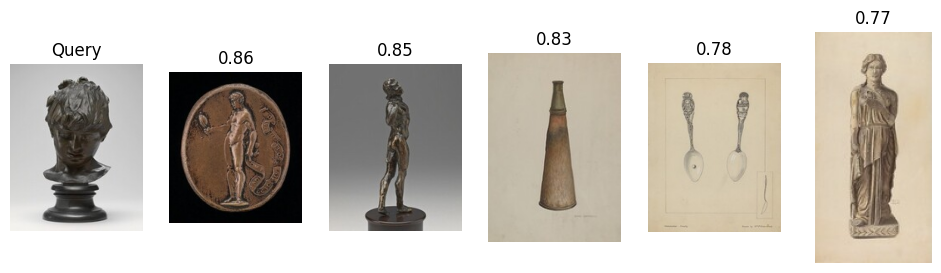

In [26]:
show_results("10.jpg")

In [27]:
similarity_scores = []

for img, emb in object_embeddings.items():

    scores = []

    for img2, emb2 in object_embeddings.items():

        if img == img2:
            continue

        scores.append(compute_similarity(emb, emb2))

    similarity_scores.append((img, np.mean(scores)))

In [28]:
outliers = sorted(similarity_scores, key=lambda x: x[1])[:5]

print("Potential outliers:", outliers)

Potential outliers: [('131.jpg', np.float64(0.5059168806985979)), ('65.jpg', np.float64(0.5119187485032451)), ('27.jpg', np.float64(0.5435433224577049)), ('163.jpg', np.float64(0.5454433189034371)), ('119.jpg', np.float64(0.548627603495852))]
